# 绘制一个月长度的INP浓度时间序列

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

In [41]:
def compute_avg(s, round_index=True):
    """
    从 Series 中提取每段非 NaN 区间的尾值，并计算：
    - 尾值的平均
    - 索引平均（可选四舍五入）
    
    参数:
        s: pd.Series
        round_index : bool, 默认为 True, 是否对 index 均值四舍五入
    
    返回:
        pd.Series, 索引 = 平均 index, 值 = 平均尾值
        如果没有任何尾值，返回一个空 Series
    """

    # 保证输入是 Series
    if not isinstance(s, pd.Series):
        raise TypeError("Input must be a pandas Series.")

    # 1. 提取每段非 NaN 区间的尾值
    mask = s.notna() & s.shift(-1).isna()
    s_last = s[mask]

    # 2. 如果没有尾值，返回空 Series
    if len(s_last) == 0:
        return pd.Series(np.nan, index=[np.mean(s.index)])

    # 3. 计算值和索引的均值
    value_mean = s_last.mean()
    index_mean = np.mean(s_last.index)

    if round_index:
        index_mean = int(round(index_mean))

    # 4. 返回带“平均索引”的 Series
    return pd.Series(value_mean, index=[index_mean])


def compute_net(sam, bac):
    """
    输入两个时间序列, 先计算两者的均值, 再计算差值(采样值-背景值)
    
    参数:
        sam: pd.Series, 采样值时间序列
        bac: pd.Series, 背景值时间序列
    返回:
        pd.Series, 差值时间序列
        若差值小于0, 则返回0
    """
    sam_avg = compute_avg(sam)
    bac_avg = compute_avg(bac)

    # 最终 index = 这两个均值索引的平均
    final_index = int(round((sam_avg.index[0] + bac_avg.index[0]) / 2))

    net = float(sam_avg.values[0] - bac_avg.values[0])

    return pd.Series(max(net, 0.0), index=[final_index])

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
[Timestamp('2025-01-01 15:34:59.919942'), Timestamp('2025-01-02 14:39:40.867145'), Timestamp('2025-01-03 14:13:05.643480'), Timestamp('2025-01-04 11:52:40.331583'), Timestamp('2025-01-05 15:53:31.014488'), Timestamp('2025-01-06 15:04:14.321982'), Timestamp('2025-01-07 14:28:42.307794'), Timestamp('2025-01-08 16:03:59.805794'), Timestamp('2025-01-09 13:48:35.339165'), Timestamp('2025-01-10 15:50:01.298816'), Timestamp('2025-01-11 16:23:07.188572'), Timestamp('2025-01-12 17:02:38.745076'), Timestamp('2025-01-13 14:17:56.301726'), Timestamp('2025-01-14 16:18:17.841032'), Timestamp('2025-01-15 14:07:41.844177'), Timestamp('2025-01-16 16:18:25.299842'), Timestamp('2025-01-17 15:51:27.799824'), Timestamp('2025-01-18 15:29:23.800380'), Timestamp('2025-01-19 17:36:28.799366'), Timestamp('2025-01-20 12:25:32.299975'), Timestamp('2025-01-21 14:22:45.800098'), Timestamp('2025-01-22 18:11:03.742078'), Timestamp('2025-01-23 15:2

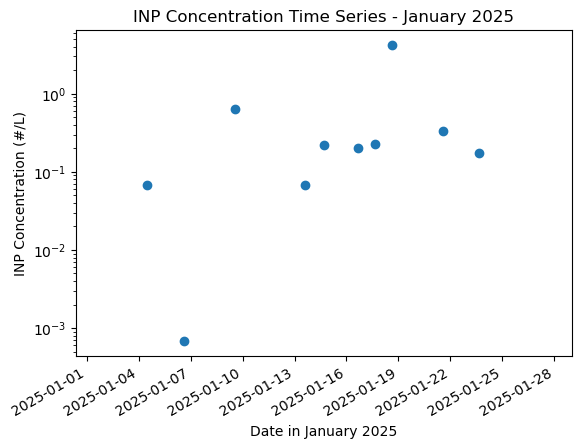

In [ ]:
# -15degC 下INP浓度时间序列(2025.01)

p = Path(r"D:\Coding\Data\Lanzhou_cfdc")

all_dates = []
all_net_INP = []
## 数据处理, 合并多天数据, 输出为DataFrame
for file in p.glob("data_202501*.csv"):# 更换月份时记得修改
    data = pd.read_csv(file).dropna(subset=['Lamina Average T [C]'])

    base_date = pd.to_datetime(file.stem.split('_')[1][0:8])
    dt = base_date + pd.to_timedelta(data['Time'], unit='s')

    x = dt
    bac_toggle = data['Background INP avg [#/L] Toggle']
    sam_toggle = data['Sample INP avg [#/L] Toggle']
    y_bac_15 = data['Background INP avg [#/L]'][bac_toggle==True][data['Lamina T Set [C]']==-15.0].reindex(x.index, fill_value=np.nan) #后期改为其他温度
    y_sam_15 = data['Sample INP avg [#/L]'][sam_toggle==True][data['Lamina T Set [C]']==-15.0].reindex(x.index, fill_value=np.nan) #后期改为其他温度
    y_avg_net_15 = compute_net(y_sam_15, y_bac_15)

    all_dates.append(x[y_avg_net_15.index[0]])
    all_net_INP.append(y_avg_net_15[y_avg_net_15.index[0]])

# 合并所有天的数据, 创建DataFrame
df = pd.DataFrame({'Date': all_dates,
                   'Net_INP-15': all_net_INP})

x = df['Date']
y = df['Net_INP-15']

fig = plt.figure()
ax = fig.add_subplot(111)
    
ax.scatter(x, y, label='Net INP avg at -15C')# 更换温度时记得修改

ax.xaxis.set_major_locator(mdates.DayLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.gcf().autofmt_xdate()# 自动旋转日期标记
ax.set_xlabel('Date in January 2025')# 更换月份时记得修改
ax.set_yscale('log')
ax.set_ylabel('INP Concentration (#/L)')
ax.set_title('INP Concentration Time Series - January 2025')# 更换月份时记得修改
plt.show()